# Linear hash fragility on structured keys

A small notebook to study why the linear family `h(x) = (a x + b) mod p` can become fragile on structured inputs.

In [4]:
from math import isqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

Two old failure modes were already suspicious:

- consecutive keys,
- arithmetic progressions.

Both can kill degree-1 buckets before peeling even starts.

## Residue occupancy analysis

For one segment, we look only at `x -> (a x + b) mod p` and count how many keys land in each residue class.

The comparison below uses three families:

- consecutive keys,
- an arithmetic progression,
- random keys in a similar range.

In [ ]:
def next_prime(n: int) -> int:
    def is_prime(k: int) -> bool:
        if k < 2:
            return False
        if k % 2 == 0:
            return k == 2
        limit = isqrt(k)
        for d in range(3, limit + 1, 2):
            if k % d == 0:
                return False
        return True

    candidate = max(2, int(n))
    while not is_prime(candidate):
        candidate += 1
    return candidate


def residue_counts(keys, a: int, b: int, p: int) -> np.ndarray:
    """
    Count how many keys land in each residue class under h(x) = (a x + b) mod p.
    
    In BDZ, each residue r in {0, ..., p-1} corresponds to a local vertex in one
    segment. Therefore, counts[r] is exactly the number of hyperedges incident to
    that vertex, i.e. its degree.
    """
    keys = np.asarray(keys, dtype=np.int64)
    residues = (a * keys + b) % p
    return np.bincount(residues, minlength=p)


def occupancy_summary(name: str, keys, a: int, b: int, p: int) -> dict:
    keys = np.asarray(keys, dtype=np.int64)
    counts = residue_counts(keys, a=a, b=b, p=p)
    return {
        "dataset": name,
        "n": len(keys),
        "span": int(keys.max() - keys.min() + 1),
        "density": len(keys) / (keys.max() - keys.min() + 1),
        "p": p,
        "min_bucket": int(counts.min()),
        "max_bucket": int(counts.max()),
        "zero_buckets": int((counts == 0).sum()),
        "deg1_buckets": int((counts == 1).sum()),
        "deg2_buckets": int((counts == 2).sum()),
        "deg3plus_buckets": int((counts >= 3).sum()),
        "bucket_std": float(counts.std()),
        "counts": counts,
    }


n = 100_000
m = int(np.ceil(1.25 * n))
p = next_prime(np.ceil(m / 3))
a = 137
b = 911

rng = np.random.default_rng(42)
random_span = 4 * n
random_keys = np.sort(rng.choice(np.arange(random_span), size=n, replace=False))

cases = [
    ("consecutive", np.arange(n, dtype=np.int64)),
    ("arith_step_3", np.arange(0, 3 * n, 3, dtype=np.int64)),
    ("random", random_keys),
]

summaries = [occupancy_summary(name, keys, a=a, b=b, p=p) for name, keys in cases]
summary_df = pd.DataFrame([{k: v for k, v in row.items() if k != "counts"} for row in summaries])
summary_df

,dataset,n,span,density,p,min_bucket,max_bucket,zero_buckets,deg1_buckets,deg2_buckets,deg3plus_buckets,bucket_std
0,consecutive,100000,100000,1.000000,41669,2,3,0,0,25007,16662,0.489870
1,arith_step_3,100000,299998,0.333336,41669,2,3,0,0,25007,16662,0.489870
2,random,100000,399987,0.250008,41669,0,9,2638,8445,12148,18438,1.348005


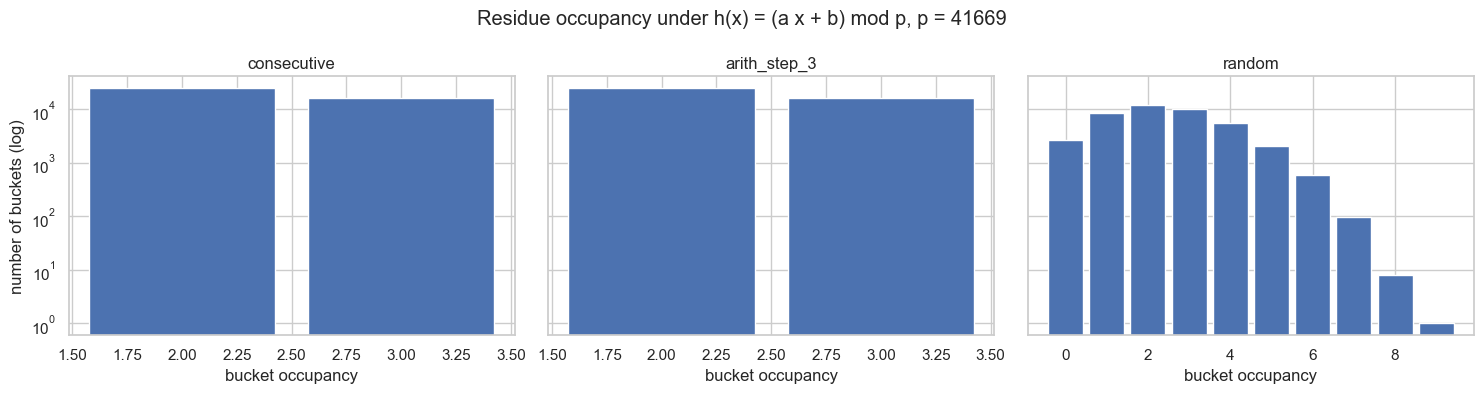

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, row in zip(axes, summaries):
    values, freqs = np.unique(row["counts"], return_counts=True)
    ax.bar(values, freqs, width=0.85)
    ax.set_title(row["dataset"])
    ax.set_xlabel("bucket occupancy")
    ax.set_yscale("log")

axes[0].set_ylabel("number of buckets (log)")
fig.suptitle(f"Residue occupancy under h(x) = (a x + b) mod p, p = {p}")
plt.tight_layout()